# Cross-Domain Few-Shot Learning for Histopathology: MAML from Colorectal to Prostate Cancer

**Author:** Rayenne Maissoune Deradra

## Overview

Digital histopathology datasets are abundant for some cancer types and scarce for others, and manual annotation by pathologists is expensive and slow. This project asks whether a model trained to recognize tissue patterns in one cancer type can be quickly adapted to a completely different cancer type using only a handful of labeled examples — a setting known as **few-shot, cross-domain classification**.

Model-Agnostic Meta-Learning (MAML) is used to meta-train a ResNet-18 backbone on a 9-class colorectal cancer histopathology dataset (**CRC-NCT-HE-100K**), then evaluate how well the learned initialization adapts, via a handful of gradient steps, to a binary benign-vs-cancer classification task on a **prostate** histopathology dataset (**SICAPv2**) that the model has never seen during meta-training.

## Why MAML

Unlike metric-based few-shot methods (e.g. Prototypical Networks) that compare embeddings to class prototypes, MAML learns a set of initial weights that are explicitly optimized to be *easy to fine-tune*. Rather than memorizing what each class looks like, the model learns how to adapt quickly to any new task from just a few labeled examples and a handful of gradient updates. This distinction matters for cross-domain transfer: the target domain (prostate tissue) has different staining, morphology, and class semantics than the source domain (colorectal tissue), so an approach built for fast adaptation is a better fit than one built for fixed class prototypes.

## Pipeline

1. **Meta-train** a MAML model on 5-way, 5-shot episodes sampled from CRC-NCT (9 classes total).
2. **Meta-test** on 2-way (binary), 5-shot episodes sampled from SICAPv2, replacing the classification head and adapting with a handful of inner-loop gradient steps per episode.
3. **Evaluate** adaptation quality against a random baseline and visualize training dynamics, the confusion matrix, and qualitative test samples.

## Requirements

- PyTorch, torchvision
- [`higher`](https://github.com/facebookresearch/higher) — enables differentiable inner-loop optimization, which is what makes the MAML outer-loop gradient possible
- CRC-NCT-HE-100K and SICAPv2 datasets


## 1. Environment Setup

MAML's outer-loop update requires differentiating *through* the inner-loop optimization steps (a gradient of gradients). Standard PyTorch optimizers update parameters in place, which breaks this chain. The [`higher`](https://github.com/facebookresearch/higher) library solves this by creating a *functional*, differentiable copy of the model for the inner loop, so gradients can flow back through it to the original (meta) parameters.

The cell below installs `higher` from a local wheel (used here instead of PyPI due to the offline Kaggle environment) and confirms the runtime has GPU access.

In [1]:
import subprocess, glob, os

# Install higher from local wheel
whl_files = glob.glob(
    '/kaggle/input/datasets/rayeneeeeeeeeee/higher-whl/**/*.whl', recursive=True)
if not whl_files:
    whl_files = glob.glob(
        '/kaggle/input/datasets/rayeneeeeeeeeee/higher-whl/**/*.tar.gz',
        recursive=True)
if not whl_files:
    # fallback: search anywhere under /kaggle/input in case the slug differs
    whl_files = [f for f in glob.glob('/kaggle/input/**/*', recursive=True)
                 if 'higher' in f.lower() and (f.endswith('.whl') or f.endswith('.tar.gz'))]

print('Found:', whl_files)
assert whl_files, 'higher wheel not found'
subprocess.run(['pip', 'install', whl_files[0],
                '--no-deps', '-q'])

import torch, os, higher
print('PyTorch :', torch.__version__)
print('higher  : OK')
print('CUDA    :', torch.cuda.is_available())
for i in range(torch.cuda.device_count()):
    print(f'  GPU {i} :', torch.cuda.get_device_name(i))

Found: ['/kaggle/input/datasets/rayeneeeeeeeeee/higher-0-2-1-py3-none-any/higher-0.2.1-py3-none-any.whl']
PyTorch : 2.10.0+cu128
higher  : OK
CUDA    : True
  GPU 0 : Tesla T4
  GPU 1 : Tesla T4


## 2. Configuration

All paths and hyperparameters are defined in one place for clarity and reproducibility.

**Meta-train setting (CRC-NCT):** 5-way, 5-shot, 10-query episodes — the model sees 5 classes per episode, 5 support images per class to adapt on, and is evaluated on 10 held-out query images per class.

**Meta-test setting (SICAPv2):** 2-way (benign vs. cancer), same 5-shot support size, but with more inner-loop adaptation steps (`ADAPT_STEPS`) than at training time, since adapting to an unseen domain is a harder problem than adapting to an unseen combination of already-seen classes.

In [2]:
import torch, os

CRC_ROOT  = '/kaggle/input/datasets/rayeneeeeeeeeee/nctcrche100k/9 Class Colon Cancer Histopathological Image'
SICAP_IMG = '/kaggle/input/datasets/rayeneeeeeeeeee/sicapv2/SICAPv2_Kaggle/Train/Images'
SICAP_MSK = '/kaggle/input/datasets/rayeneeeeeeeeee/sicapv2/SICAPv2_Kaggle/Train/Masks'
OUT_DIR   = '/kaggle/working'
CKPT_PATH = os.path.join(OUT_DIR, 'maml_crossdomain_best.pt')

# ── Meta-train config (CRC-NCT 9-class) ──────────────────────
N_WAY_TRAIN = 5    # 5-way on CRC during training
K_SHOT      = 5
Q_QUERY     = 10
META_BS     = 2

INNER_STEPS          = 5
INNER_LR             = 0.01
OUTER_LR             = 0.0001
NUM_EPOCHS           = 20
COPY_INITIAL_WEIGHTS = False

TRAIN_EPS = 400
VAL_EPS   = 100

# ── Meta-test config (SICAPv2 binary) ────────────────────────
N_WAY_TEST  = 2    # binary: benign vs cancer
TEST_EPS    = 100
ADAPT_STEPS = 10   # more steps at test time for cross-domain

IMG_SIZE = 128
DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f'Device     : {DEVICE}')
print(f'Meta-train : {N_WAY_TRAIN}-way {K_SHOT}-shot on CRC-NCT')
print(f'Meta-test  : {N_WAY_TEST}-way {K_SHOT}-shot on SICAPv2')
print(f'Adapt steps: {ADAPT_STEPS} (more than training for cross-domain)')

Device     : cuda
Meta-train : 5-way 5-shot on CRC-NCT
Meta-test  : 2-way 5-shot on SICAPv2
Adapt steps: 10 (more than training for cross-domain)


## 3. Data Loading and Label Construction

**CRC-NCT-HE-100K** provides 100,000 H&E-stained image patches across 9 tissue classes (tumor, stroma, lymphocytes, mucosa, adipose, background, etc.), giving a large, class-balanced pool from which to sample meta-training episodes. Images are split 70% / 15% / 15% into meta-train / meta-validation splits (the remaining 15% is unused here).

**SICAPv2** provides prostate biopsy images with pixel-level Gleason-pattern masks rather than single image-level labels. To obtain a binary *benign vs. cancer* label per image, a mask-based thresholding rule is applied:
- an image is labeled **cancer** if more than 30% of its mask pixels are marked as a tumor pattern,
- an image is labeled **benign** if over 50% of its mask is benign tissue and less than 10% shows any tumor pattern.

Images that fall between these thresholds (mixed/ambiguous tissue) are discarded to keep the binary labels clean. The benign class is also capped at 2,000 images to avoid a heavily imbalanced pool before episodic sampling.

In [3]:
import os, random
import numpy as np
from PIL import Image

random.seed(42)

# ── CRC-NCT 9-class ───────────────────────────────────────────
classes = sorted([
    d for d in os.listdir(CRC_ROOT)
    if os.path.isdir(os.path.join(CRC_ROOT, d))])

class_to_files = {}
for c in classes:
    folder = os.path.join(CRC_ROOT, c)
    files  = [
        os.path.join(folder, f)
        for f in os.listdir(folder)
        if f.lower().endswith(
            ('.jpg','.jpeg','.png','.tif'))]
    class_to_files[c] = files
    print(f'  {c:45s}: {len(files):6,}')
print(f'Total: {sum(len(v) for v in class_to_files.values()):,}')

def make_img_dict(class_to_files, fs, fe):
    d = {}
    for c, files in class_to_files.items():
        f = files[:]
        random.shuffle(f)
        d[c] = f[int(fs*len(f)) : int(fe*len(f))]
    return d

crc_train = make_img_dict(class_to_files, 0.00, 0.70)
crc_val   = make_img_dict(class_to_files, 0.70, 0.85)

# ── SICAPv2 binary from masks ─────────────────────────────────
def get_sicap_binary(img_dir, mask_dir,
                     cancer_thresh=0.30,
                     max_benign=2000, seed=42):
    random.seed(seed)
    cancer, benign = [], []
    for fname in sorted(os.listdir(img_dir)):
        mpath = os.path.join(mask_dir, fname)
        ipath = os.path.join(img_dir,  fname)
        if not os.path.exists(mpath): continue
        mask  = np.array(Image.open(mpath))
        c_pct = (mask == 100).sum() / mask.size
        b_pct = (mask == 0).sum()   / mask.size
        if c_pct > cancer_thresh:
            cancer.append(ipath)
        elif b_pct > 0.5 and c_pct < 0.10:
            benign.append(ipath)
    random.shuffle(benign)
    benign = benign[:max_benign]
    print(f'SICAPv2: {len(cancer)} cancer, {len(benign)} benign')
    return {'benign': benign, 'cancer': cancer}

print('\nLoading SICAPv2...')
sicap_data = get_sicap_binary(SICAP_IMG, SICAP_MSK)
sicap_test = make_img_dict(sicap_data, 0.85, 1.00)
print(f'SICAPv2 test: '
      f'{sum(len(v) for v in sicap_test.values())} images')

  1. Normal                                    :  8,763
  2. Tumor                                     : 14,317
  3. Stroma                                    : 10,446
  4. Lympho                                    : 11,557
  5. Complex                                   : 13,536
  6. Debris                                    : 11,512
  7. Mucosa                                    :  8,896
  8. Adipose                                   : 10,407
  9. Background                                : 10,566
Total: 100,000

Loading SICAPv2...
SICAPv2: 1293 cancer, 2000 benign
SICAPv2 test: 494 images


## 4. Episodic Dataset Construction

MAML (and few-shot learning generally) is trained and evaluated in **episodes** rather than on a fixed train/test split of individual images. Each episode simulates a miniature classification task:

- **N-way**: how many classes are sampled for this episode
- **K-shot**: how many labeled *support* examples per class the model gets to adapt on
- **Q-query**: how many held-out *query* examples per class are used to evaluate that adaptation

`FSLDataset` implements this: on every call it randomly samples `N_WAY` classes, then `K_SHOT + Q_QUERY` images per class, and returns a (support, query) pair with matching labels. Separate episodic dataloaders are built for CRC-NCT training (5-way), CRC-NCT validation (5-way), and SICAPv2 testing (2-way, binary). Light augmentation (flips, color jitter) is applied only to the training episodes to improve generalization without distorting the validation/test signal.

In [4]:
import torch, random
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T


class FSLDataset(Dataset):
    def __init__(self, class_dict, n_way, k_shot, q_query,
                 n_episodes, img_size=128, augment=False):
        super().__init__()
        self.class_dict = class_dict
        self.classes    = list(class_dict.keys())
        self.n_way      = n_way
        self.k_shot     = k_shot
        self.q_query    = q_query
        self.n_episodes = n_episodes

        need  = k_shot + q_query
        short = [c for c, f in class_dict.items()
                 if len(f) < need]
        assert not short, f'Too few images: {short}'

        aug = [
            T.RandomHorizontalFlip(),
            T.RandomVerticalFlip(),
            T.ColorJitter(0.2, 0.2, 0.2, 0.05),
        ] if augment else []

        self.transform = T.Compose(aug + [
            T.Resize([img_size, img_size]),
            T.ToTensor(),
            T.Normalize([0.485, 0.456, 0.406],
                        [0.229, 0.224, 0.225]),
        ])

    def __len__(self): return self.n_episodes

    def _load(self, path):
        return self.transform(
            Image.open(path).convert('RGB'))

    def __getitem__(self, _):
        chosen = random.sample(self.classes, self.n_way)
        sup_imgs, qry_imgs = [], []
        sup_tgts, qry_tgts = [], []
        for label, cls in enumerate(chosen):
            paths = random.sample(
                self.class_dict[cls],
                self.k_shot + self.q_query)
            for p in paths[:self.k_shot]:
                sup_imgs.append(self._load(p))
                sup_tgts.append(label)
            for p in paths[self.k_shot:]:
                qry_imgs.append(self._load(p))
                qry_tgts.append(label)
        return (torch.stack(sup_imgs),
                torch.stack(qry_imgs),
                torch.LongTensor(sup_tgts),
                torch.LongTensor(qry_tgts))


def collate_episodes(batch): return batch


# CRC-NCT train/val dataloaders (5-way)
train_ds = FSLDataset(crc_train, N_WAY_TRAIN, K_SHOT,
                      Q_QUERY, TRAIN_EPS,
                      IMG_SIZE, augment=True)
val_ds   = FSLDataset(crc_val, N_WAY_TRAIN, K_SHOT,
                      Q_QUERY, VAL_EPS, IMG_SIZE)

train_dl = DataLoader(train_ds, META_BS, shuffle=True,
                      num_workers=2,
                      collate_fn=collate_episodes)
val_dl   = DataLoader(val_ds, META_BS, shuffle=False,
                      num_workers=2,
                      collate_fn=collate_episodes)

# SICAPv2 test dataloader (2-way)
test_ds = FSLDataset(sicap_test, N_WAY_TEST, K_SHOT,
                     Q_QUERY, TEST_EPS, IMG_SIZE)
test_dl = DataLoader(test_ds, META_BS, shuffle=False,
                     num_workers=2,
                     collate_fn=collate_episodes)

print(f'CRC train : {len(train_dl)} batches ({N_WAY_TRAIN}-way)')
print(f'CRC val   : {len(val_dl)} batches ({N_WAY_TRAIN}-way)')
print(f'SICAP test: {len(test_dl)} batches ({N_WAY_TEST}-way)')

CRC train : 200 batches (5-way)
CRC val   : 50 batches (5-way)
SICAP test: 50 batches (2-way)


## 5. Model Architecture

A ResNet-18 pretrained on ImageNet is split into two parts:

- **Frozen backbone** (`conv1` through `layer3`): provides stable, general-purpose low-level and mid-level visual features (edges, textures, local structure). These are *not* updated during meta-training or meta-testing, which keeps the number of meta-learned parameters small and reduces the risk of overfitting to the source domain.
- **Meta-learned layers** (`layer4` + linear classifier head): these are the only parameters updated by MAML's inner and outer loops. `layer4` captures higher-level, more task-specific features, which is exactly what needs to change when adapting to a new domain or task.

At meta-test time, the classifier head (trained for 5-way CRC-NCT classification) is swapped for a fresh 2-way head, since SICAPv2 is a binary classification problem with no class overlap with the source domain.

In [5]:
import torch.nn as nn
import torchvision.models as models


class MAMLResNet(nn.Module):
    """
    Identical to your working CRC-NCT MAML.
    Frozen : conv1, bn1, relu, maxpool, layer1-3
    Meta   : layer4 + classifier head

    At meta-test time the head is replaced with
    a 2-class head for binary SICAPv2 classification.
    """
    def __init__(self, n_class):
        super().__init__()
        backbone = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT)

        self.frozen = nn.Sequential(
            backbone.conv1, backbone.bn1,
            backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2,
            backbone.layer3,
        )
        for p in self.frozen.parameters():
            p.requires_grad = False

        self.meta_layer = backbone.layer4
        self.avgpool    = backbone.avgpool
        self.classifier = nn.Linear(512, n_class)
        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, x):
        with torch.no_grad():
            x = self.frozen(x)
        x = self.meta_layer(x)
        x = self.avgpool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


# Build with N_WAY_TRAIN classes for training
model = MAMLResNet(N_WAY_TRAIN).to(DEVICE)

frozen_p    = sum(p.numel() for p in
                  model.frozen.parameters())
trainable_p = sum(p.numel() for p in
                  model.parameters()
                  if p.requires_grad)
print(f'Frozen params    : {frozen_p:,}')
print(f'Trainable params : {trainable_p:,}')

dummy  = torch.zeros(4, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
logits = model(dummy)
print(f'Output shape     : {tuple(logits.shape)}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 224MB/s]


Frozen params    : 2,782,784
Trainable params : 8,396,293
Output shape     : (4, 5)


## 6. MAML Inner/Outer Loop

For each episode:

1. **Inner loop**: starting from the current meta-parameters, the model is fine-tuned for `INNER_STEPS` SGD steps on the *support* set only, using `higher`'s differentiable functional model (`fmodel`) so this adaptation remains part of the computation graph.
2. **Outer loss**: the *adapted* model is evaluated on the *query* set, producing a loss that reflects how good the original meta-parameters were as a starting point for fast adaptation.
3. **Outer loop**: query losses are averaged across a batch of episodes (`META_BS`) and backpropagated through the entire inner-loop trajectory to update the meta-parameters.

During evaluation (`phase='eval'`), `track_higher_grads` is disabled since no outer-loop update is needed, which saves memory.

In [6]:
import higher, gc

def accuracy(logits, targets):
    return (logits.argmax(1) == targets
            ).float().mean().item() * 100


def run_epoch(model, loader, optimizer=None,
              phase='train', n_way=None):
    ce       = nn.CrossEntropyLoss()
    is_train = (phase == 'train')
    nway     = n_way or N_WAY_TRAIN
    all_acc, all_loss = [], []

    model.train() if is_train else model.eval()

    for batch in loader:
        if is_train:
            optimizer.zero_grad(set_to_none=True)

        meta_loss = torch.tensor(0.0, device=DEVICE)
        batch_acc = []

        for (support, query, s_tgt, q_tgt) in batch:
            support = support.to(DEVICE)
            query   = query.to(DEVICE)
            s_tgt   = s_tgt.to(DEVICE)
            q_tgt   = q_tgt.to(DEVICE)

            inner_opt = torch.optim.SGD(
                model.parameters(), lr=INNER_LR)

            with higher.innerloop_ctx(
                model, inner_opt,
                copy_initial_weights=COPY_INITIAL_WEIGHTS,
                track_higher_grads=is_train,
            ) as (fmodel, diffopt):
                for _ in range(INNER_STEPS):
                    s_loss = ce(fmodel(support), s_tgt)
                    diffopt.step(s_loss)
                q_logits   = fmodel(query)
                outer_loss = ce(q_logits, q_tgt)

            meta_loss = meta_loss + outer_loss
            batch_acc.append(
                accuracy(q_logits.detach().cpu(),
                         q_tgt.cpu()))

        meta_loss = meta_loss / len(batch)
        if is_train:
            meta_loss.backward()
            nn.utils.clip_grad_norm_(
                model.parameters(), 10.0)
            optimizer.step()

        all_loss.append(meta_loss.item())
        all_acc.extend(batch_acc)

    return (sum(all_acc) / len(all_acc),
            sum(all_loss) / len(all_loss))


print('accuracy + run_epoch defined OK')

accuracy + run_epoch defined OK


## 7. Meta-Training on CRC-NCT

The model is meta-trained for up to `NUM_EPOCHS` epochs of 5-way, 5-shot episodes, using Adam as the outer-loop optimizer with cosine annealing and gradient clipping for stability. Early stopping (patience-based) and checkpointing on best validation accuracy protect against overfitting to the training episodes and ensure the best-performing meta-parameters are what gets carried forward into the cross-domain test.

In [7]:
import time

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad,
           model.parameters()), lr=OUTER_LR)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=1e-7)

best_val_acc = 0.0
no_improve   = 0
patience     = 6
history = {
    'train_acc': [], 'val_acc': [],
    'train_loss': [], 'val_loss': [],
}

print(f'Meta-training MAML on CRC-NCT — {NUM_EPOCHS} epochs')
print(f'{N_WAY_TRAIN}-way {K_SHOT}-shot | '
      f'inner {INNER_STEPS} steps LR={INNER_LR}')
print(f'Outer LR={OUTER_LR} | patience={patience}')
print('=' * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_acc,  tr_loss  = run_epoch(
        model, train_dl, optimizer, 'train')
    val_acc, val_loss = run_epoch(
        model, val_dl, phase='eval')
    scheduler.step()

    history['train_acc'].append(tr_acc)
    history['val_acc'].append(val_acc)
    history['train_loss'].append(tr_loss)
    history['val_loss'].append(val_loss)

    print(f'Ep {epoch:02d}/{NUM_EPOCHS}  '
          f'Train {tr_acc:5.2f}% loss={tr_loss:.4f}  '
          f'Val {val_acc:5.2f}% loss={val_loss:.4f}  '
          f'({time.time()-t0:.0f}s)')

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve   = 0
        torch.save(model.state_dict(), CKPT_PATH)
        print(f'  -> Saved (best val={best_val_acc:.2f}%)')
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f'  Early stop at epoch {epoch}')
            break

    torch.cuda.empty_cache()
    gc.collect()

print('=' * 60)
print(f'Training done. Best val: {best_val_acc:.2f}%')

Meta-training MAML on CRC-NCT — 20 epochs
5-way 5-shot | inner 5 steps LR=0.01
Outer LR=0.0001 | patience=6
Ep 01/20  Train 72.09% loss=0.7937  Val 82.16% loss=0.5549  (183s)
  -> Saved (best val=82.16%)
Ep 02/20  Train 89.92% loss=0.3214  Val 84.36% loss=0.4872  (167s)
  -> Saved (best val=84.36%)
Ep 03/20  Train 93.71% loss=0.1983  Val 87.42% loss=0.3869  (168s)
  -> Saved (best val=87.42%)
Ep 04/20  Train 95.03% loss=0.1576  Val 87.20% loss=0.3859  (156s)
Ep 05/20  Train 95.84% loss=0.1293  Val 88.82% loss=0.3564  (153s)
  -> Saved (best val=88.82%)
Ep 06/20  Train 96.13% loss=0.1191  Val 88.84% loss=0.3448  (152s)
  -> Saved (best val=88.84%)
Ep 07/20  Train 96.58% loss=0.1089  Val 89.30% loss=0.3339  (151s)
  -> Saved (best val=89.30%)
Ep 08/20  Train 96.61% loss=0.1006  Val 89.64% loss=0.3438  (150s)
  -> Saved (best val=89.64%)
Ep 09/20  Train 97.02% loss=0.0955  Val 88.70% loss=0.3728  (150s)
Ep 10/20  Train 97.10% loss=0.0876  Val 90.30% loss=0.3349  (150s)
  -> Saved (best va

## 8. Cross-Domain Meta-Test on SICAPv2

This is the core experiment: the best CRC-NCT checkpoint is loaded, its 5-way head is replaced with a fresh, randomly initialized 2-way head, and the model is evaluated on 2-way binary episodes sampled from SICAPv2 — a domain and label space it has never encountered during meta-training.

More inner-loop adaptation steps (`ADAPT_STEPS`) are used here than during meta-training (`INNER_STEPS`), since the new classifier head starts from random weights and the domain shift (colorectal → prostate tissue) means the frozen and meta-learned features must work harder to separate the new classes. Performance is compared against the random-guess baseline (50% for a balanced binary task) to quantify how much the meta-learned initialization actually helps.

In [8]:
# ── Cross-domain meta-test on SICAPv2 ────────────────────────
# Load best checkpoint trained on CRC-NCT
model.load_state_dict(
    torch.load(CKPT_PATH, map_location=DEVICE))

# Replace 5-class head with 2-class head for binary SICAPv2
model.classifier = nn.Linear(512, N_WAY_TEST).to(DEVICE)
nn.init.xavier_uniform_(model.classifier.weight)
nn.init.zeros_(model.classifier.bias)
model.eval()

print(f'Head replaced: {N_WAY_TRAIN}-class → {N_WAY_TEST}-class')
print(f'Adapting with {ADAPT_STEPS} inner steps '
      f'(vs {INNER_STEPS} during training)')
print(f'Testing on SICAPv2 binary — {TEST_EPS} episodes')
print('-' * 60)

ce = nn.CrossEntropyLoss()
test_accs, test_losses = [], []
all_preds, all_labels  = [], []

for batch in test_dl:
    for (support, query, s_tgt, q_tgt) in batch:
        support = support.to(DEVICE)
        query   = query.to(DEVICE)
        s_tgt   = s_tgt.to(DEVICE)
        q_tgt   = q_tgt.to(DEVICE)

        # Adapt using more steps for cross-domain
        inner_opt = torch.optim.SGD(
            model.parameters(), lr=INNER_LR)

        with higher.innerloop_ctx(
            model, inner_opt,
            copy_initial_weights=True,
            track_higher_grads=False,
        ) as (fmodel, diffopt):
            for _ in range(ADAPT_STEPS):
                s_loss = ce(fmodel(support), s_tgt)
                diffopt.step(s_loss)
            with torch.no_grad():
                q_logits = fmodel(query)
                q_loss   = ce(q_logits, q_tgt)
                preds    = q_logits.argmax(1).cpu().numpy()

        acc = accuracy(q_logits.detach().cpu(), q_tgt.cpu())
        test_accs.append(acc)
        test_losses.append(q_loss.item())
        all_preds.extend(preds)
        all_labels.extend(q_tgt.cpu().numpy())

test_acc  = sum(test_accs)   / len(test_accs)
test_loss = sum(test_losses) / len(test_losses)
baseline  = 100.0 / N_WAY_TEST

print(f'\n{"="*55}')
print(f'MAML Cross-Domain: CRC-NCT → SICAPv2')
print(f'{"="*55}')
print(f'Test accuracy   : {test_acc:.2f}%')
print(f'Test loss       : {test_loss:.4f}')
print(f'Random baseline : {baseline:.1f}%')
print(f'Gain over random: +{test_acc-baseline:.2f}%')
print(f'{"="*55}')

Head replaced: 5-class → 2-class
Adapting with 10 inner steps (vs 5 during training)
Testing on SICAPv2 binary — 100 episodes
------------------------------------------------------------

MAML Cross-Domain: CRC-NCT → SICAPv2
Test accuracy   : 65.30%
Test loss       : 0.6469
Random baseline : 50.0%
Gain over random: +15.30%


## 9. Results

The figure below summarizes the full experiment:

1. **Meta-train accuracy** — training vs. validation accuracy across epochs on CRC-NCT, against the 5-way random baseline.
2. **Meta-train loss** — training vs. validation cross-entropy loss, to check for overfitting.
3. **Confusion matrix** — row-normalized benign/cancer predictions on the SICAPv2 test episodes.
4. **Qualitative samples** — example benign (green border) and cancer (red border) patches from the SICAPv2 test set, for visual sanity-checking of what the model is classifying.

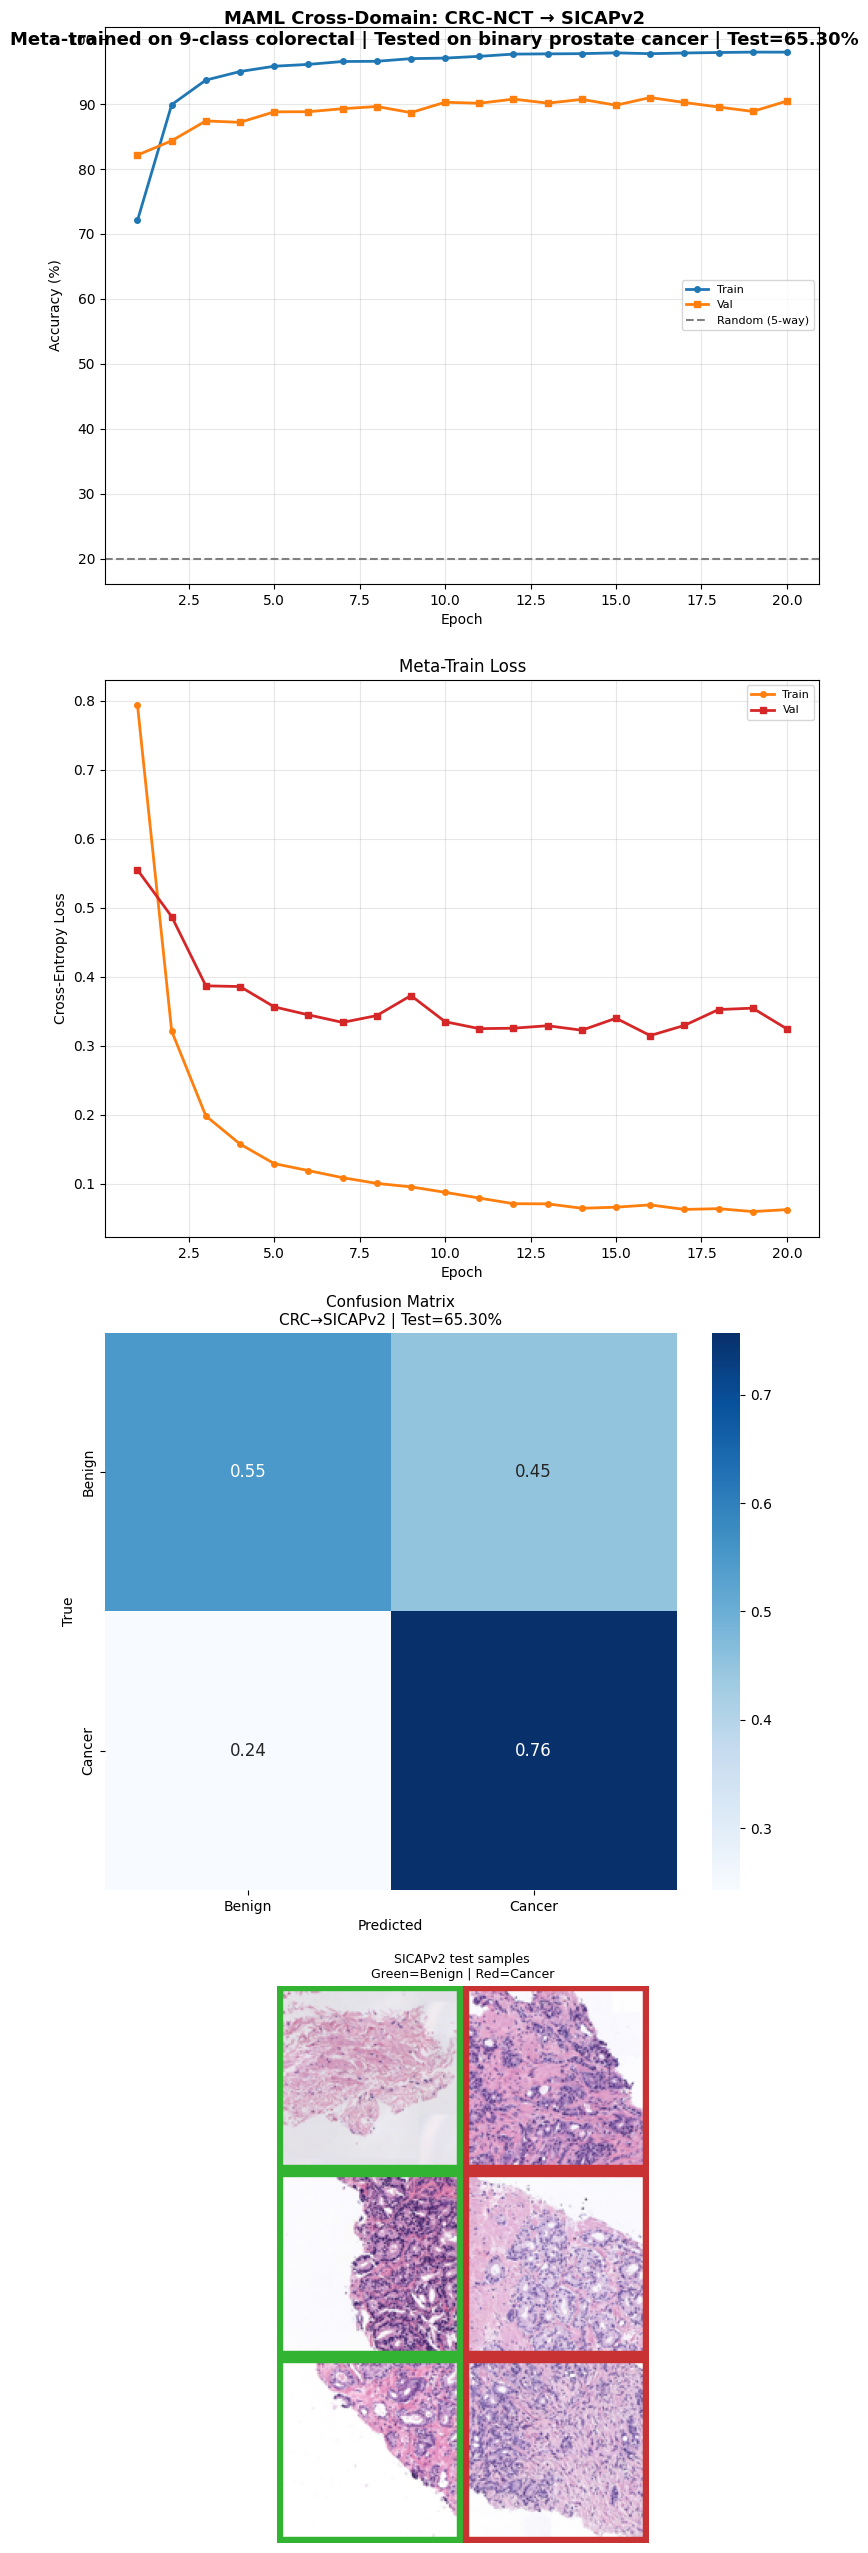

Classification report:
              precision    recall  f1-score   support

      Benign       0.69      0.55      0.61      1000
      Cancer       0.63      0.76      0.69      1000

    accuracy                           0.65      2000
   macro avg       0.66      0.65      0.65      2000
weighted avg       0.66      0.65      0.65      2000

Saved.


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image

baseline = 100.0 / N_WAY_TEST
class_names = ['Benign', 'Cancer']

fig = plt.figure(figsize=(8, 26))

# ── 1. Training curves: accuracy ─────────────────────────────
ax1 = fig.add_subplot(4, 1, 1)
actual_ep = len(history['train_acc'])
ep = range(1, actual_ep + 1)
ax1.plot(ep, history['train_acc'], 'o-', label='Train', markersize=4, linewidth=2)
ax1.plot(ep, history['val_acc'], 's-', label='Val', markersize=4, linewidth=2)
ax1.axhline(100 / N_WAY_TRAIN, color='gray', linestyle='--', linewidth=1.5,
            label=f'Random ({N_WAY_TRAIN}-way)')

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# ── 2. Training curves: loss ─────────────────────────────────
ax2 = fig.add_subplot(4, 1, 2)
ax2.plot(ep, history['train_loss'], 'o-', label='Train', markersize=4, linewidth=2, color='tab:orange')
ax2.plot(ep, history['val_loss'], 's-', label='Val', markersize=4, linewidth=2, color='tab:red')
ax2.set_title('Meta-Train Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Cross-Entropy Loss')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# ── 3. Confusion matrix ──────────────────────────────────────
ax3 = fig.add_subplot(4, 1, 3)
cm = confusion_matrix(all_labels, all_preds)
cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_n, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=ax3,
            annot_kws={'size': 12})
ax3.set_title(f'Confusion Matrix\nCRC→SICAPv2 | Test={test_acc:.2f}%', fontsize=11)
ax3.set_xlabel('Predicted')
ax3.set_ylabel('True')

# ── 4. Sample patches ────────────────────────────────────────
random.seed(42)
ax4 = fig.add_subplot(4, 1, 4)

def make_strip(paths, border_color, n=3):
    sampled = random.sample(list(paths), min(n, len(paths)))
    strip = []
    for p in sampled:
        img = np.array(Image.open(p).convert('RGB').resize((112, 112)))
        bordered = np.ones((120, 120, 3), dtype=np.uint8)
        bordered[:, :] = [50, 180, 50] if border_color == 'green' else [200, 50, 50]
        bordered[4:116, 4:116] = img
        strip.append(bordered)
    return np.concatenate(strip, axis=0)

benign_strip = make_strip(sicap_test['benign'], 'green')
cancer_strip = make_strip(sicap_test['cancer'], 'red')
combined = np.concatenate([benign_strip, cancer_strip], axis=1)
ax4.imshow(combined)
ax4.set_title('SICAPv2 test samples\nGreen=Benign | Red=Cancer', fontsize=9)
ax4.axis('off')

plt.suptitle(
    f'MAML Cross-Domain: CRC-NCT → SICAPv2\n'
    f'Meta-trained on 9-class colorectal | Tested on binary prostate cancer | Test={test_acc:.2f}%',
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'maml_crossdomain_results.png'), dpi=150)
plt.show()

print('Classification report:')
print(classification_report(all_labels, all_preds, target_names=class_names))
print('Saved.')

## References

- Finn, C., Abbeel, P., & Levine, S. (2017). *Model-Agnostic Meta-Learning for Fast Adaptation of Deep Networks.* ICML.
- Kather, J. N., et al. (2018). *100,000 histological images of human colorectal cancer and healthy tissue* (CRC-NCT-HE-100K). Zenodo.
- Silva-Rodríguez, J., et al. (2020). *Going Deeper through the Gleason Scoring Scale: An Automatic End-to-End Classification, Grading, and Generation Framework for Prostate Biopsy Samples* (SICAPv2).
